<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 5
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Metropolis sampling
</h2>

In this exercise we make use of the $M(RT)^2$ algorithm to sample a generic probability distribution. The algorithm is based on the properties of discrete Markov processes. In particular, it relies on the fact that, given a probability density function, the goal is to find the underlying stochastic transfer matrix whose invariant distribution is the desired probability density.
The fundamental theorem state: if one can find a regular transition matrix $K(x|y)$ such that our $p(x)$ is invariant distribution for K, then
$$
p(x)=\lim\limits_{n\to\infty}d_{n+1}=\lim\limits_{n\to\infty}\int dy K(x|y)d_n(y) \forall d_1(x).
$$
If we have an initial probability $d_1$ to be in a state x and K satisfying the previous requests, our distribution converge to the desired one.

**How should the stochastic kernel K be chosen?**

The transfer matrix K has to satisfy the integral equation 
$$
p(x)=\int dyK(x|y)p(y)
$$
such that p is an invariant distribution of K. It's an integral equation, but the detailed balance
$$
K(x|y)p(y)=K(y|x)p(x)
$$
ensures that the previous condition on K holds. A possible choice is
$$
K(x|y)=T(x|y)\times \min[1, \frac{T(y|x)p(x)}{T(x|y)p(y)}].
$$
In particular, when the proposal distribution (T(x|y)) is symmetric, the acceptance criterion reduces to the ratio of the two probability densities, which is known. Notice also that this ratio does not require the normalization of the probability density, since the normalization constant cancels out.

**Efficency**
Due to the fact the Metropolis alghoritm converge asymptotically, the process need to be equilibrate before. So we have to push our chain in a region where the target probability density is significant. Due to the kind of acceptation function used, the efficiency of the algorithm also depends on the choice of the proposal distribution (T(x|y)). If the proposed step is too large, the new point is likely to fall outside the high-probability region, so that $p(x')/p(x)\ll1$ and the move is rejected (the new points has very low probability).

On the other hand, if the proposed step is too small, $p(x')/p(x)\simeq1$, consecutive configurations become highly correlated and the Markov chain explores the configuration space very slowly. 
A good compromise between these two regimes is obtained by tuning the proposal step so that the average acceptance probability is approximately $A(x|y)\simeq0.5$.

<p style="color: blue; font-size: 25px; font-weight: bold;">
EXERCISE 5.1:
</p>
In this exercise, we use the $M(RT)^2$ to sample the probability densities of the 1s and 2s orbital for the hydrogen athom. The expectation value of the radius is computed, together with statistical errors using data-blocking. Finally, the sampled probability density is visualized. 

As trial function T for proposing new points, we first used a uniform probability distribution and then a Gaussian distribution. Both functions are symmetryc.

In both simulation the starting point is taken at a distance of $10a_0$ (Bohr radius) in order to exploit how the $M(RT)^2$ converges and how many equilibration step are needed.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def load_radius(filename):
    data = np.loadtxt(filename, skiprows=1)

    blocks = data[:, 0]
    r = data[:, 1]
    err_r = data[:, 2]

    return blocks, r, err_r

def plot_radius(filename, title, orb):
    blocks, r, err = load_radius(filename)

    plt.errorbar(blocks, r, yerr=err, label='Metro')
    if orb=="1s":
        plt.axhline(1.5, color='r', ls='--', label='Theory')
    elif orb=="2p":
        plt.axhline(5, color='r', ls='--', label='Theory')
    plt.xlabel("# Blocks")
    plt.ylabel(r"$\langle r \rangle / a_0$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final value: {r[-1]:.4f} ± {err[-1]:.4f}")

# Carciamento accettanze
def load_acceptance(equi_file, run_file):
    eq_acc = np.loadtxt(equi_file)
    run_acc = np.loadtxt(run_file)

    step = eq_acc[:, 0]
    equi_accept = eq_acc[:, 1]

    blocks = run_acc[:, 0]
    run_accept = run_acc[:, 1]

    return step, equi_accept, blocks, run_accept

def plot_acceptance(eq_file, run_file, title, rate):
    step, equi_acc, blocks, run_acc = load_acceptance(eq_file, run_file)
    Mean_accep = np.mean(run_acc)
    print("Accettanza media nei blocchi: ", Mean_accep)

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    ax[0].plot(step, equi_acc)
    ax[0].set_title(f"Acceptance during equilibration; rate = {rate}")
    ax[0].set_xlabel("eq_step")
    ax[0].set_ylabel("Acceptance")
    ax[0].grid(True)

    ax[1].plot(blocks, run_acc)
    ax[1].axhline(Mean_accep, color='r', ls='--', label=f'Mean acceptance = {Mean_accep:.3f}')
    ax[1].set_title(f"Acceptance with blocks; rate = {rate}")
    ax[1].set_xlabel("block")
    ax[1].set_ylabel("Acceptance")
    ax[1].grid(True)
    ax[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_points(filename, title):
    data = np.loadtxt(filename, skiprows=1)

    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')

    ax.scatter(x, y, z, c=z, s=2, marker='.')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_label("z")
    ax.set_title(title)

    ax.view_init(10, 30)

    plt.show()

<p style="color: green; font-size: 18px; font-weight: bold;">
UNIFORM 1s (1, 0, 0)
</p>

Accettanza media nei blocchi:  0.5155959999999999


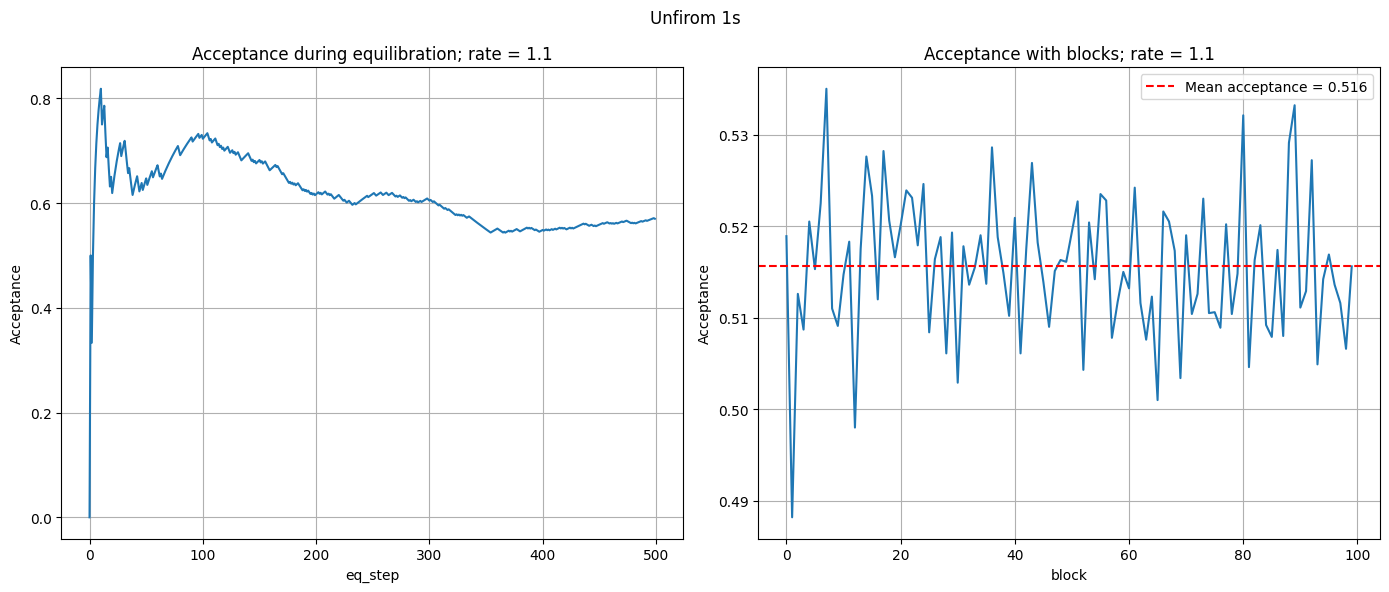

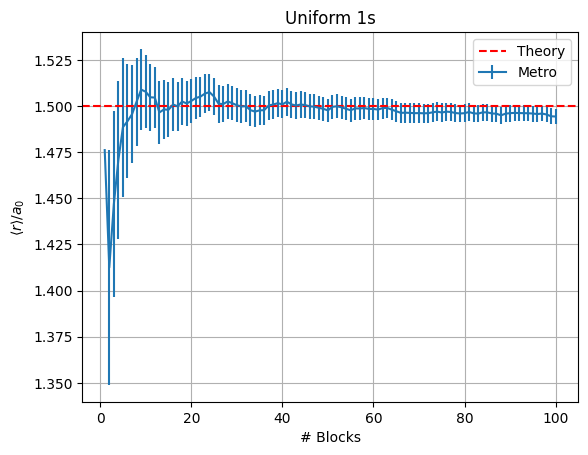

Final value: 1.4943 ± 0.0043


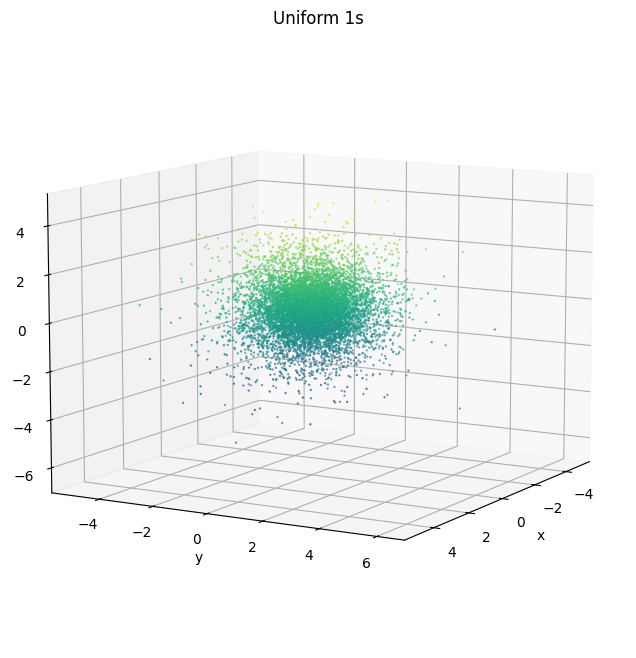

In [26]:
plot_acceptance("./OUTPUT/equil_acc_100_rate_1.1.dat", "./OUTPUT/run_acc_100_rate_1.1.dat", "Unfirom 1s", 1.1)
plot_radius("./OUTPUT/mean_r_100.dat", "Uniform 1s", "1s")
plot_points("./OUTPUT/points_100.xyz", "Uniform 1s")

<p style="color: green; font-size: 18px; font-weight: bold;">
UNIFORM 2p (2, 1, 0)
</p>

Accettanza media nei blocchi:  0.5086660000000001


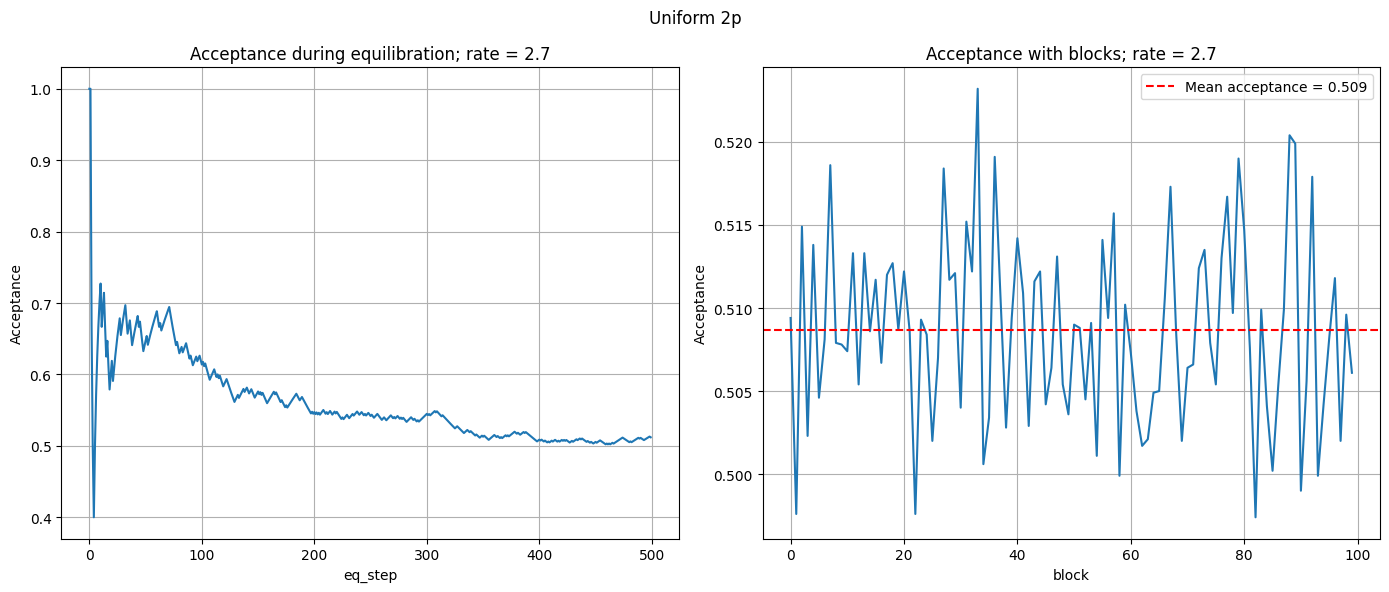

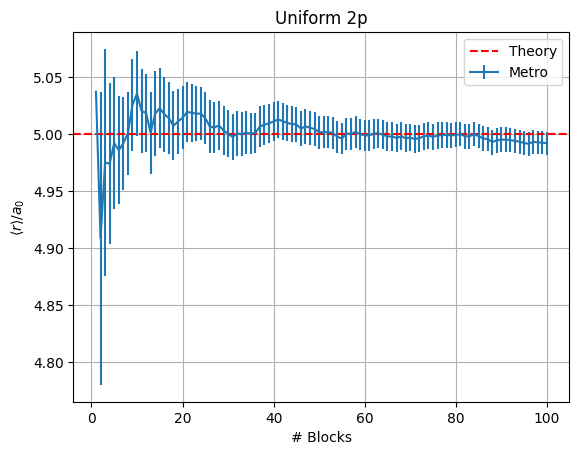

Final value: 4.9921 ± 0.0101


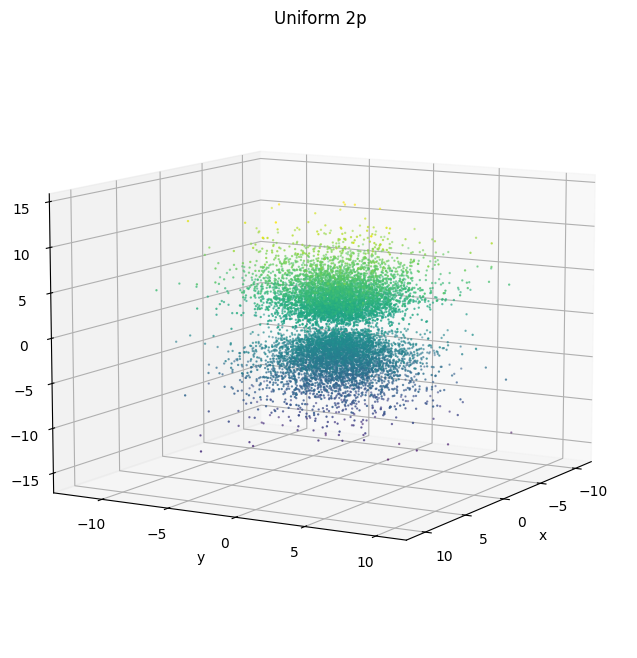

In [27]:
plot_acceptance("./OUTPUT/equil_acc_210_rate_2.7.dat", "./OUTPUT/run_acc_210_rate_2.7.dat", "Uniform 2p", 2.7)
plot_radius("./OUTPUT/mean_r_210.dat", "Uniform 2p", "2p")
plot_points("./OUTPUT/points_210.xyz", "Uniform 2p")

<p style="color: green; font-size: 18px; font-weight: bold;">
GAUSSAIN 1s (1, 0, 0)
</p>

Accettanza media nei blocchi:  0.52973


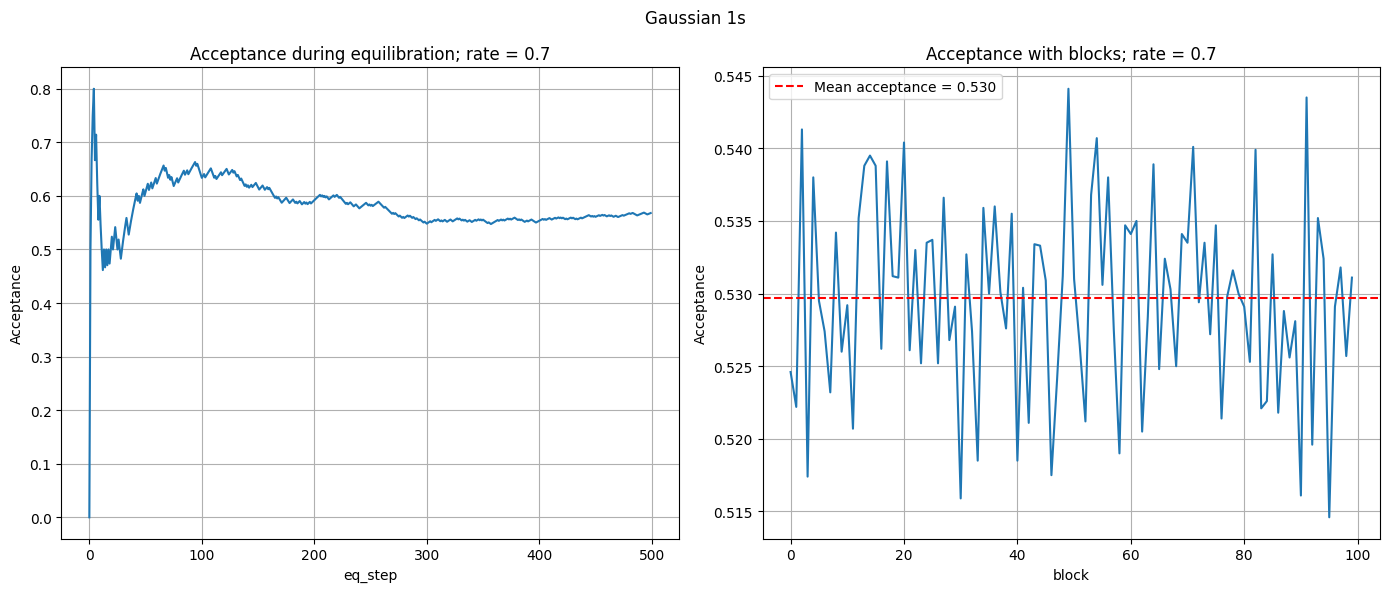

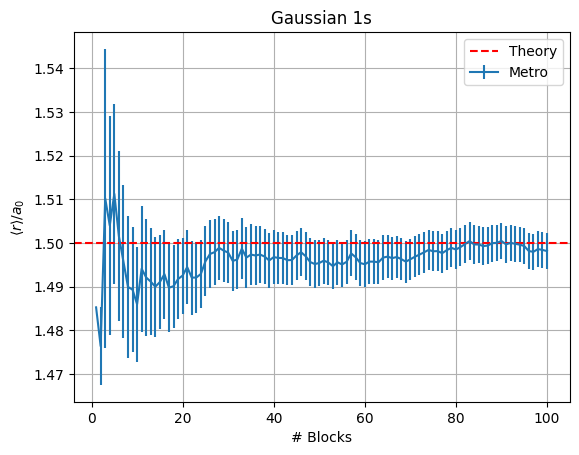

Final value: 1.4981 ± 0.0041


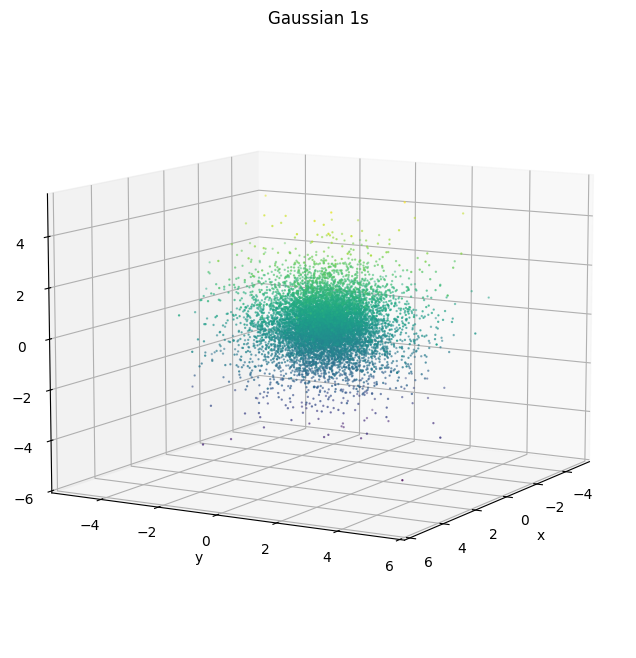

In [28]:
plot_acceptance("./OUTPUT/equil_acc_100_rate_0.7_Gauss.dat", "./OUTPUT/run_acc_100_rate_0.7_Gauss.dat", "Gaussian 1s", 0.7)
plot_radius("./OUTPUT/mean_r_100_Gauss.dat", "Gaussian 1s", "1s")
plot_points("./OUTPUT/points_100_Gauss.xyz", "Gaussian 1s")

<p style="color: green; font-size: 18px; font-weight: bold;">
GAUSSIAN 2p (2, 1, 0)
</p>

Accettanza media nei blocchi:  0.514698


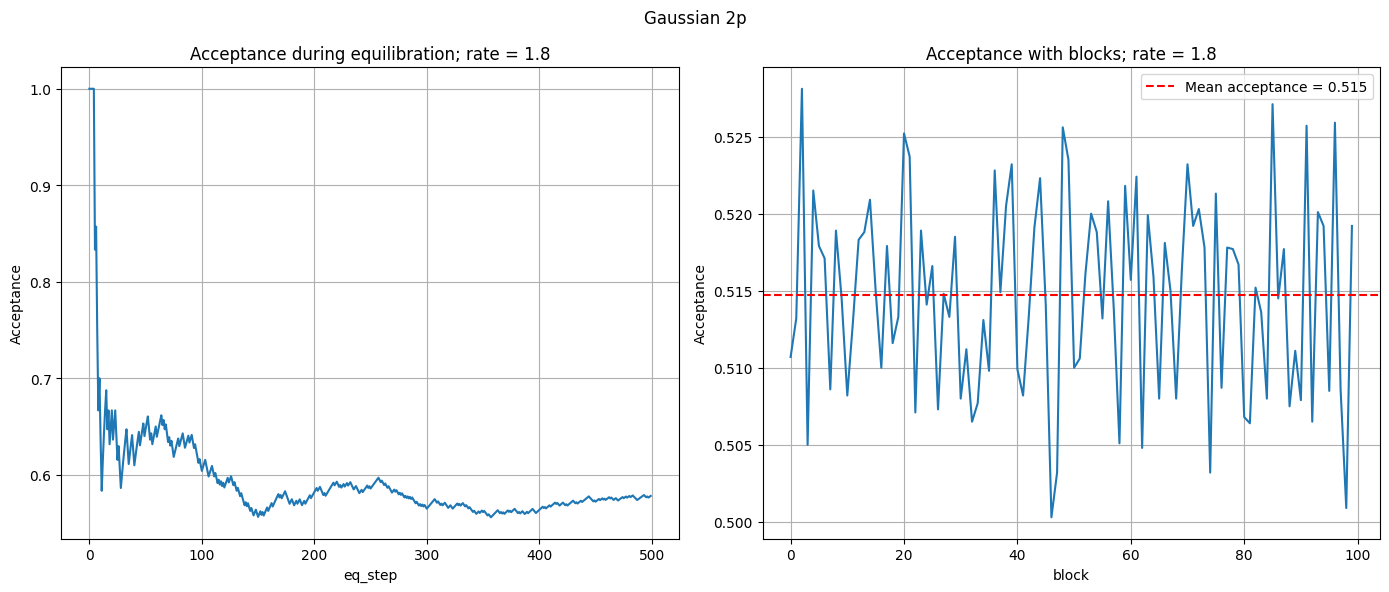

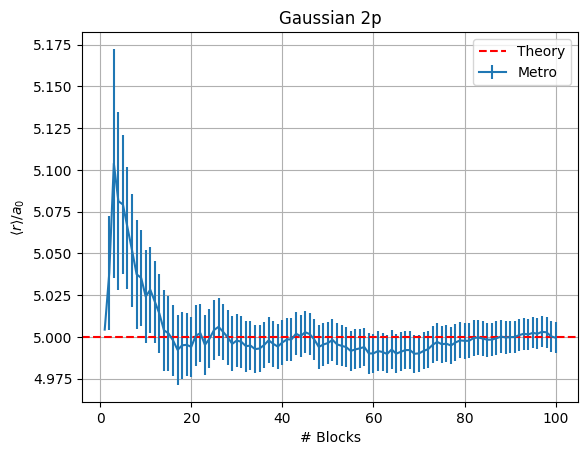

Final value: 4.9995 ± 0.0093


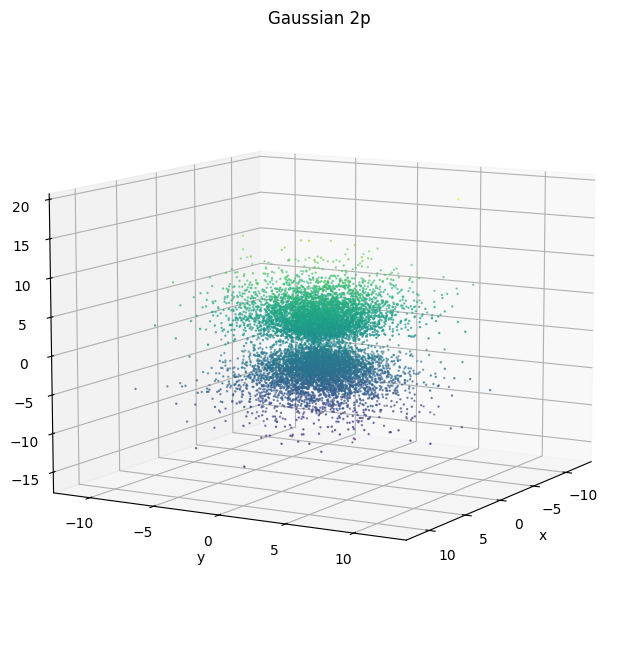

In [29]:
plot_acceptance("./OUTPUT/equil_acc_210_rate_1.8_Gauss.dat", "./OUTPUT/run_acc_210_rate_1.8_Gauss.dat", "Gaussian 2p", 1.8)
plot_radius("./OUTPUT/mean_r_210_Gauss.dat", "Gaussian 2p", "2p")
plot_points("./OUTPUT/points_210_Gauss.xyz", "Gaussian 2p")

In both the uniform and Gaussian transition cases, notice that the (2p) orbital requires a larger step length in order to achieve an acceptance rate of approximately (50%). Furthermore, the Gaussian transition requires a smaller step size than the uniform transition. This behavior highlights the dependence of the algorithm on the underlying random walk that defines the Markov chain.